In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import unet_ein as ue

In [13]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [14]:
import random

In [15]:
import pytorch_ssim

# Data

In [16]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [17]:
trn_.data= trn_.data[80*220:]

In [18]:
bs = 8
seq_len = 10
overlap=0

In [19]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [20]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [21]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

# Custom Loss

In [22]:
class SSIM:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        tgt_lka,tgt_vis,ip_lka,ip_vis = ip
        
        #tgt_lka = tgt_lka [None,None,None,:]
        #ip_lka = ip_lka [None,None,None,:]
        
        tgt_vis = tgt_vis [None,None,None,:]
        ip_vis = ip_vis [None,None,None,:]
        
        lka = 0#self.ssim_loss(ip_lka,tgt_lka)
        vis = self.ssim_loss(ip_vis,tgt_vis)
        return 1-((lka+vis))

In [23]:
class binary:
    def __call__(self,ip,tgt):
        tgt_lka,tgt_vis,ip_lka,ip_vis = ip
        
        vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        return (lka+vis)

In [24]:
class mse:
    def __call__(self,ip,tgt):
        tgt_lka,tgt_vis,ip_lka,ip_vis = ip
        
        vis = nn.functional.mse_loss(ip_vis[:88],tgt_vis[:88])
        lka = 0#nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        return (lka+vis)

In [25]:
loss = binary()

# Model : Combined
Input: LKA + VIS <br>
Input Form: Full frame<br>
Output: Reconstruction<br>
Training Dataset:Original<br>

In [28]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.randint(0,2,(88,)).cuda()
        self.lka = torch.zeros(88).type(torch.LongTensor).cuda()

        
        self.combined_signal_compressor = nn.Sequential(nn.Linear(88*2,256*4),
                                                        nn.Dropout(0.5),
                                                        nn.PReLU(),
                                                        nn.Linear(256*4,88*2),
                                                        nn.Dropout(0.5),
                                                        nn.PReLU(),
                                                        nn.Linear(88*2,88*1),
                                                        nn.Dropout(0.5),
                                                        nn.PReLU(),
                                                        nn.Linear(88*1,88*2),
                                                        nn.Sigmoid())
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
    def forward(self,x):
        
        #self.lka = torch.zeros(88).type(torch.LongTensor).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
            
        #if lka_idx.size or self.c in [200,280] :
        #    print(self.c)
            #self.lka = x.view(80,-1)[lka_idx[0]][120:208]
        #    self.lka =torch.logical_xor(m.lka.type(torch.BoolTensor),torch.ones_like(m.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
            

        
        cat = torch.cat([self.lka.type(torch.LongTensor).cuda(),self.vis.type(torch.LongTensor).cuda()])

        out = self.combined_signal_compressor(cat.type(torch.FloatTensor).cuda())
        
        #print([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka.type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),out[:88].type(torch.FloatTensor).cuda(),out[88:]


In [29]:
m =  unet_seq(bs,seq_len).cuda()

In [30]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [31]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [32]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [33]:
learn.fit(m , opt , 4 , dl,loss  )

  1%|          | 17/1837 [00:00<00:30, 59.50it/s, loss : 0.6950942768770105]

[886, 924, 739, 595, 806]


 33%|███▎      | 609/1837 [00:05<00:11, 108.33it/s, loss : 0.31057162981706693]

fake


 41%|████      | 752/1837 [00:06<00:09, 108.68it/s, loss : 0.34900734272408995]

...

fake


 54%|█████▎    | 986/1837 [00:09<00:07, 107.24it/s, loss : 0.05006585885254897] 

fake


 99%|█████████▉| 510/515 [00:03<00:00, 136.58it/s, loss : 0.08559280844295726]]  

train Loss:  0.07443622499704361   validation loss:  0.08544415980577469
tensor(nan)


In [34]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(88).type(torch.LongTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[5]

In [107]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 9/1837 [00:00<00:20, 87.30it/s]

testing...


 94%|█████████▎| 1722/1837 [00:12<00:00, 132.74it/s]

fake


  2%|▏         | 11/515 [00:00<00:04, 106.81it/s]/s]

testing...


  1%|          | 9/1224 [00:00<00:14, 86.01it/s]s]

testing...


100%|█████████▉| 1220/1224 [00:09<00:00, 136.47it/s]

In [108]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [109]:
#index 203735 in the sheet

In [110]:
lka = [i[0][0]*0.1 for i in m.flag_list]

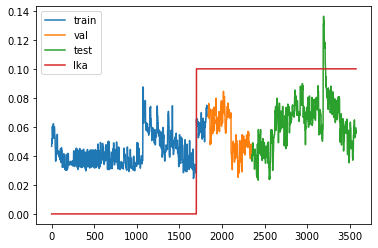

In [111]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [104]:
#path = 'Models/publication/recon lka vis/combined/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

In [105]:
path = 'Models/publication/recon lka vis/combined/4/'
fig.savefig(f'{path}i.png')
save(path,[a,b,c],names=['normal','attack','train'])

testing...


  2%|▏         | 9/515 [00:00<00:05, 88.11it/s]it/s]

testing...


  1%|          | 10/1224 [00:00<00:12, 96.61it/s]]

testing...


...

  1%|          | 9/1224 [00:00<00:14, 86.22it/s]s]

testing...


  5%|▌         | 66/1224 [00:00<00:09, 120.07it/s]

fake


 99%|█████████▉| 1210/1224 [00:08<00:00, 136.41it/s]

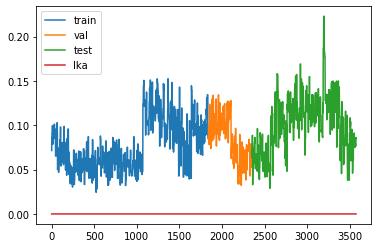

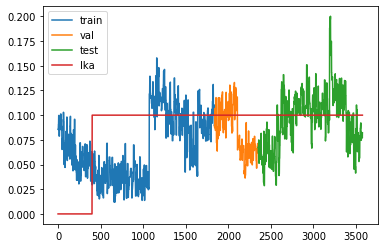

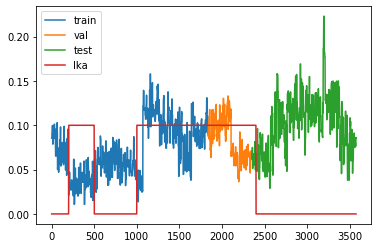

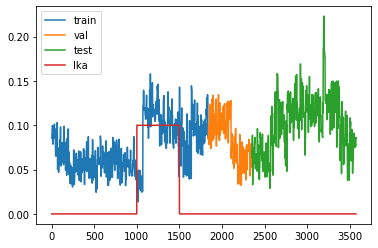

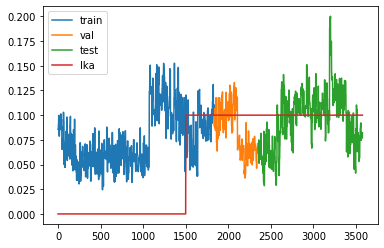

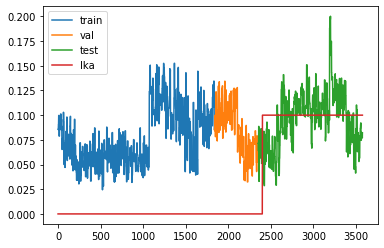

In [35]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(88).type(torch.LongTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.1 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/recon lka vis/SSIM/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

In [40]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

In [37]:
#d 8 EC F6 7C 9A 2F E3 93 10  Length = 219910 BitCount = 114 ID = 1707

In [38]:
#d 8 08 F7 7C 7C 2F A4 A0 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 08 F7 7C 7C 2F A4 A0 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 09 D7 7C 74 0F A4 8E 10  Length = 223910 BitCount = 116 ID = 1707

In [39]:
#d 8 CB F6 7C 7C 2F E4 9A 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 CC E6 7C 7A 2F 63 93 10  Length = 217910 BitCount = 113 ID = 1707
#d 8 CC E6 7C 7E 2F 23 93 10  Length = 219910 BitCount = 114 ID = 1707

In [ ]:
#d 8 B3 07 75 12 10 09 4F 11  Length = 217910 BitCount = 113 ID = 1707
#d 8 B5 87 75 12 70 C9 5D 11  Length = 213910 BitCount = 111 ID = 1707
#d 8 B5 87 75 12 70 C9 5D 11  Length = 213910 BitCount = 111 ID = 1707

In [ ]:
torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]).shape

# Model : LKA VIS ADD
Input: LKA + VIS <br>
Input Form: Full frame<br>
Output: Reconstruction  (VIS + LKA) ==> VIS , LKA<br>
Training Dataset: Original<br>

In [175]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(1).cuda()
        
        
        self.lka_compressor = nn.Sequential(nn.Linear(1,256*2),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*2,88),
                                            nn.Dropout(0.1))
        
        self.combined_signal_compressor = nn.Sequential(nn.Linear(88,256*4),
                                                        nn.Dropout(0.8),
                                                        nn.PReLU(),
                                                        nn.Linear(256*4,88//2),
                                                        nn.Dropout(0.5),
                                                        nn.PReLU(),
                                                        nn.Linear(88//2,88*1),
                                                        nn.Dropout(0.2),
                                                        nn.PReLU(),
                                                        nn.Linear(88*1,88*2),
                                                        nn.Sigmoid())
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
        
        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
            
            
        
        lka_reconstrunct = self.lka_compressor(self.lka.type(torch.FloatTensor).cuda())
        
        cat = torch.relu(self.vis + self.lka)
        out = self.combined_signal_compressor(cat)
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka.expand(88).type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),out[:88].type(torch.FloatTensor).cuda(),out[88:]


In [176]:
m =  unet_seq(bs,seq_len).cuda()

In [177]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [178]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [179]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [180]:
learn.fit(m , opt , 4 , dl,loss  )

  1%|          | 19/1837 [00:00<00:23, 77.15it/s, loss : 0.44141734273810135]

[945, 249, 446]


 14%|█▍        | 265/1837 [00:02<00:13, 120.50it/s, loss : 0.45879723890772406]

fake


 25%|██▍       | 459/1837 [00:03<00:11, 118.51it/s, loss : 0.5382918480434709] 

...

fake


 39%|███▉      | 722/1837 [00:06<00:09, 121.43it/s, loss : 0.0318088346571143]  

fake


 99%|█████████▊| 508/515 [00:03<00:00, 128.25it/s, loss : 0.047269922541821094]] 

train Loss:  0.03894077241420746   validation loss:  0.04735855013132095
tensor(nan)


In [181]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(1).type(torch.LongTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [182]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 12%|█▏        | 222/1837 [00:01<00:12, 129.19it/s]

fake


 28%|██▊       | 518/1837 [00:04<00:10, 131.27it/s]

fake


...

  0%|          | 6/1224 [00:00<00:20, 59.09it/s]s]

testing...


  6%|▌         | 73/1224 [00:00<00:10, 105.31it/s]

fake


 99%|█████████▉| 1214/1224 [00:09<00:00, 130.17it/s]

In [183]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [184]:
#index 203735 in the sheet

In [187]:
lka = [i[0][0]*0.1for i in m.flag_list]

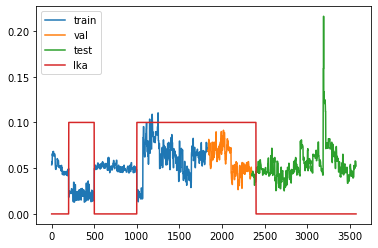

In [188]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [142]:
path = 'Models/publication/recon LKA VIS add/combined/'
cbs.save_all(path,model=m,learn=learn,opt=opt)

In [124]:
#path = 'Models/publication/recon lka vis/combined/4/'
#fig.savefig(f'{path}i.png')
#save(path,[a,b,c],names=['normal','attack','train'])

  0%|          | 8/1837 [00:00<00:23, 77.10it/s]

testing...


  1%|▏         | 7/515 [00:00<00:07, 68.05it/s]it/s]

testing...


  1%|          | 8/1224 [00:00<00:15, 78.01it/s]s]

...

  1%|          | 8/1224 [00:00<00:15, 78.73it/s]s]

testing...


 73%|███████▎  | 897/1224 [00:06<00:02, 136.15it/s]

fake


100%|█████████▉| 1222/1224 [00:08<00:00, 139.77it/s]

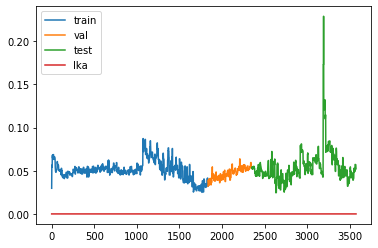

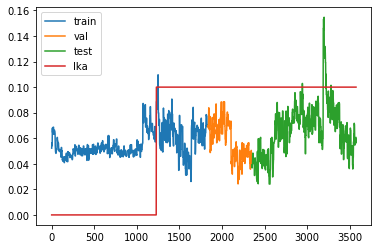

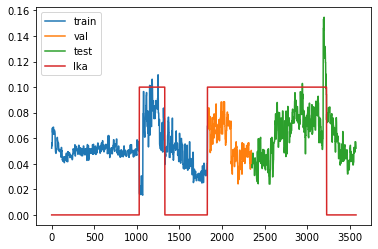

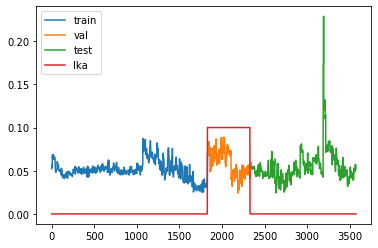

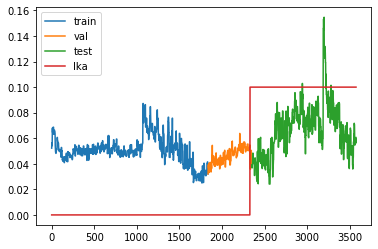

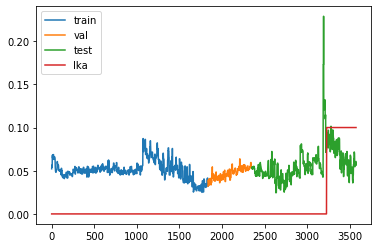

In [144]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.LongTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.1 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/recon LKA VIS add/combined/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

In [40]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model : Predict VIS
Input: Previous VIS <br>
Input Form: Full frame<br>
Output: Prediction  (Previous VIS) ==> VIS <br>
Training Dataset: Original<br>

In [211]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88,256*2),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*2,88),
                                            nn.Sigmoid())
        
        
        self.previous_vis = torch.zeros(88).cuda()
        
        self.flag_list = []
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.LongTensor).cuda()
               
        predected_vis = self.vis_compressor(self.previous_vis)
        
        self.previous_vis = self.vis.detach().data

        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.lka.type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),None,predected_vis


Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fb1cc50>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 124, in join
    res = self._popen.wait(timeout)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 50, in wait
    return self.poll(os.WNOHANG if timeout == 0.0 else 0)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 28, in poll
    pid, sts = os.waitpid(self.pid, flag)
KeyboardInterrupt: 


In [212]:
m =  unet_seq(bs,seq_len).cuda()

In [213]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [214]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [215]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [216]:
learn.fit(m , opt , 4 , dl,loss  )

  1%|          | 21/1837 [00:00<00:20, 86.96it/s, loss : 0.21793894540695918]

[525, 469, 762, 592, 734, 943, 988]


 27%|██▋       | 490/1837 [00:03<00:10, 129.35it/s, loss : 0.0726074997259646] 

fake


 30%|██▉       | 543/1837 [00:04<00:09, 129.66it/s, loss : 0.06917477180944621]

...

fake
fake


 45%|████▌     | 829/1837 [00:06<00:07, 132.42it/s, loss : 0.02548893513236604] 

fake


 98%|█████████▊| 503/515 [00:03<00:00, 125.56it/s, loss : 0.059094044133635684]] 

train Loss:  0.03169407695531845   validation loss:  0.05950392782688141
tensor(nan)


In [181]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(88).type(torch.LongTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [182]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 12%|█▏        | 222/1837 [00:01<00:12, 129.19it/s]

fake


 28%|██▊       | 518/1837 [00:04<00:10, 131.27it/s]

fake


...

  0%|          | 6/1224 [00:00<00:20, 59.09it/s]s]

testing...


  6%|▌         | 73/1224 [00:00<00:10, 105.31it/s]

fake


 99%|█████████▉| 1214/1224 [00:09<00:00, 130.17it/s]

In [183]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [184]:
#index 203735 in the sheet

In [187]:
lka = [i[0][0]*0.1for i in m.flag_list]

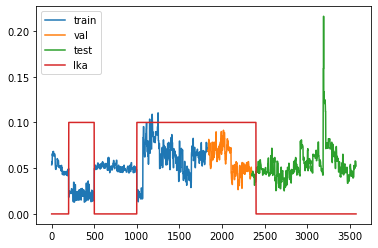

In [188]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [217]:
path = 'Models/publication/predict vis/combined/'
cbs.save_all(path,model=m,learn=learn,opt=opt)

In [124]:
#path = 'Models/publication/recon lka vis/combined/4/'
#fig.savefig(f'{path}i.png')
#save(path,[a,b,c],names=['normal','attack','train'])

  0%|          | 8/1837 [00:00<00:23, 76.79it/s]

testing...


  2%|▏         | 9/515 [00:00<00:05, 86.18it/s]it/s]

testing...


  1%|          | 7/1224 [00:00<00:17, 68.77it/s]s]

...

testing...


  1%|          | 10/1224 [00:00<00:12, 99.04it/s]]

testing...


 93%|█████████▎| 1144/1224 [00:08<00:00, 130.46it/s]

KeyboardInterrupt: 

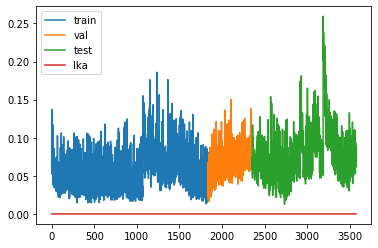

In [218]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(1).type(torch.LongTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.1 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/predict vis/combined/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

# Model : predective model for VIS with history
Input: VIS History + Previous VIS <br>
Input Form: Full frame<br>
Output: Prediction   VIS <br>
Training Dataset: Original<br>

In [226]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88*2,256*2),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*2,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(80,-1)[lka_idx[0]][120:208]
            
            
            
        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_vis = self.vis_compressor(self.drop(torch.cat([self.previous_vis,history])))
        torch.sigmoid_(predected_vis)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        
        return self.lka,self.vis,None,predected_vis


In [227]:
m =  unet_seq(bs,seq_len).cuda()

In [228]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [229]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [230]:
learn.fit(m , opt , 8 , dl,loss  )

 15%|█▌        | 278/1837 [00:02<00:12, 127.72it/s, loss : 0.0934750673582228] 

KeyboardInterrupt: 

In [39]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  1%|          | 9/1224 [00:00<00:14, 85.41it/s]s]

testing...


 99%|█████████▉| 1211/1224 [00:09<00:00, 120.65it/s]

In [40]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

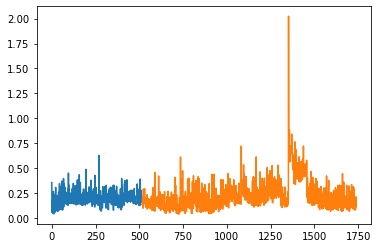

In [41]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

In [50]:
b

tensor([0.1656, 0.1657, 0.1657,  ..., 0.1992, 0.1081, 0.2134])

# Model : predict VIS with history with current lka
Input: VIS History + Previous VIS + LKA <br>
Input Form: Full frame<br>
Output: Prediction   VIS <br>
Training Dataset: Original<br>

In [243]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88*3,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*4,88),
                                            nn.Sigmoid())
        
        
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        self.drop = nn.Dropout(0.5)
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()
            
     
        
        
        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_vis = self.vis_compressor(torch.cat([self.previous_vis,history,self.lka]))
        
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        
        return self.lka.type(torch.FloatTensor).cuda(),self.vis.type(torch.FloatTensor).cuda(),None,predected_vis


Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff316337f60>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 124, in join
    res = self._popen.wait(timeout)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 50, in wait
    return self.poll(os.WNOHANG if timeout == 0.0 else 0)
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/popen_fork.py", line 28, in poll
    pid, sts = os.waitpid(self.pid, flag)
KeyboardInterrupt: 


In [256]:
m =  unet_seq(bs,seq_len).cuda()

In [257]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [258]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [259]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [266]:
loss =SSIM()

In [267]:
learn.fit(m , opt , 4 , dl,loss  )

                                                 Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff3843d8240>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff3843d8240>>
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff3843d8240>>
Traceback (most recent call last):
  0%|          | 4/1837 [00:00<00:54, 33.62it/s, loss : 0.2910793721675873]Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff3843d8240>>
  Fi

fake


 22%|██▏       | 403/1837 [00:03<00:12, 114.22it/s, loss : 0.1254553404398651] 

fake


 26%|██▌       | 478/1837 [00:04<00:11, 118.13it/s, loss : 0.11762192857814134]

...

fake


 44%|████▍     | 805/1837 [00:06<00:08, 124.57it/s, loss : 0.04215083151870633] 

fake


 15%|█▌        | 78/515 [00:00<00:03, 123.17it/s, loss : 0.08441694577534993]405]Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
    w.join()
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.uti

[740, 693, 232, 818, 460, 738, 9]
train Loss:  0.059413690119981766   validation loss:  0.1235872432589531
tensor(nan)


In [181]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
m.lka = torch.zeros(88).type(torch.LongTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400]]
m.art_lka = l[2]

In [182]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


 12%|█▏        | 222/1837 [00:01<00:12, 129.19it/s]

fake


 28%|██▊       | 518/1837 [00:04<00:10, 131.27it/s]

fake


...

  0%|          | 6/1224 [00:00<00:20, 59.09it/s]s]

testing...


  6%|▌         | 73/1224 [00:00<00:10, 105.31it/s]

fake


 99%|█████████▉| 1214/1224 [00:09<00:00, 130.17it/s]

In [183]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [184]:
#index 203735 in the sheet

In [187]:
lka = [i[0][0]*0.1for i in m.flag_list]

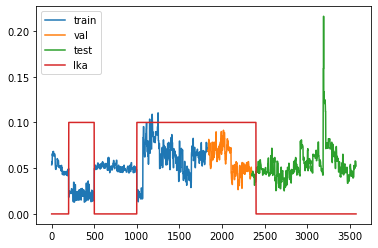

In [188]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [268]:
path = 'Models/publication/predict vis/SSIM/'
cbs.save_all(path,model=m,learn=learn,opt=opt)

In [124]:
#path = 'Models/publication/recon lka vis/combined/4/'
#fig.savefig(f'{path}i.png')
#save(path,[a,b,c],names=['normal','attack','train'])

  0%|          | 9/1837 [00:00<00:20, 90.00it/s]

testing...


  2%|▏         | 37/1837 [00:00<00:16, 108.64it/s]Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7ff37fe9ef28>>
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataload

testing...


  1%|          | 9/1224 [00:00<00:13, 88.22it/s]s]

...

  1%|          | 9/1224 [00:00<00:14, 82.93it/s]s]

testing...


  5%|▌         | 67/1224 [00:00<00:27, 41.82it/s] 

fake


100%|█████████▉| 1222/1224 [00:09<00:00, 136.43it/s]

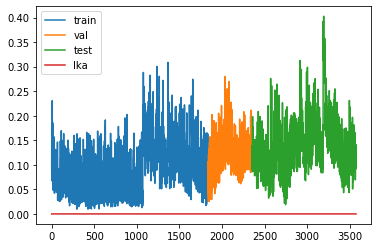

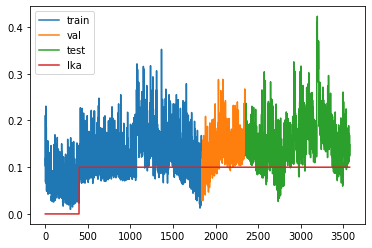

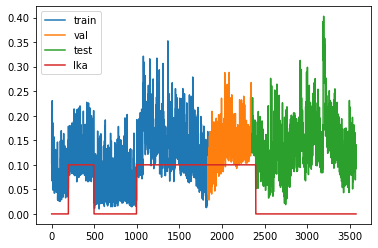

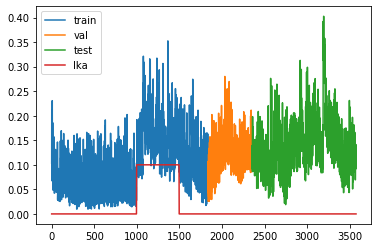

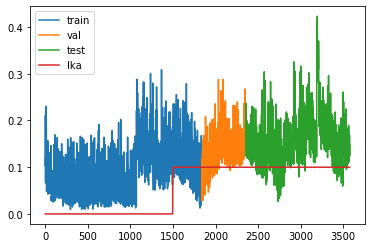

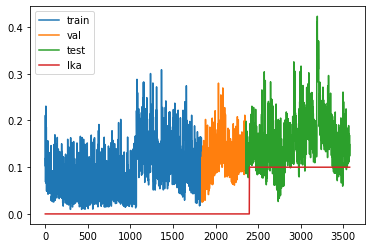

In [269]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(88).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.1 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/predict vis/SSIM/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

# Model : Predict LKA
Input: VIS History + Previous VIS + VIS <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [50]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*3,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.8),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.c =0
        self.art_lka = []
        self.test = True
        self.max_count= 2352
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:208] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_lka]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis])))
        torch.sigmoid_(predected_lka)
        
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis.detach().cpu()])
        self.c = (self.c + 1) % self.max_count
        return self.vis.type(torch.FloatTensor).cuda(),self.lka.type(torch.FloatTensor).cuda(),None,predected_lka


In [51]:
m =  unet_seq(bs,seq_len).cuda()

In [53]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [54]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [55]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [56]:
loss =binary()

In [33]:
cbs.load_all('publication/predict lka/bin/',model=m,opt=opt,learn=learn)

In [57]:
learn.fit(m , opt , 4 , dl,loss  )

  0%|          | 6/1837 [00:00<00:31, 57.81it/s, loss : 0.5803647438685099]

[152, 155, 948, 542, 889]


  9%|▉         | 168/1837 [00:01<00:13, 126.03it/s, loss : 0.6010386603219169]

fake
fake


 31%|███       | 561/1837 [00:04<00:09, 132.56it/s, loss : 0.3214685504661737] 

...

[34]


  3%|▎         | 61/1837 [00:00<00:16, 108.37it/s, loss : 0.16478796474269178]  

fake


 98%|█████████▊| 504/515 [00:03<00:00, 133.61it/s, loss : 5.420179583043569e-06]  

train Loss:  0.005698713008314371   validation loss:  5.413306553236907e-06
tensor(nan)


In [139]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
#m.lka = torch.zeros(88).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,1050,1300,1350,1900,1950,2500],[1000,1500],[1500],[2400]]
m.art_lka = l[2]#range(0,3500,50)

In [140]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 9/1837 [00:00<00:20, 89.71it/s]

testing...


 12%|█▏        | 222/1837 [00:01<00:11, 137.36it/s]

fake


 28%|██▊       | 521/1837 [00:03<00:09, 138.87it/s]

...

  1%|          | 10/1224 [00:00<00:12, 98.11it/s]]

testing...


 14%|█▍        | 171/1224 [00:01<00:07, 138.76it/s]

fake


 99%|█████████▉| 1214/1224 [00:08<00:00, 137.75it/s]

In [141]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [142]:
#index 203735 in the sheet

In [143]:
lka = [i[0][0]for i in m.flag_list]

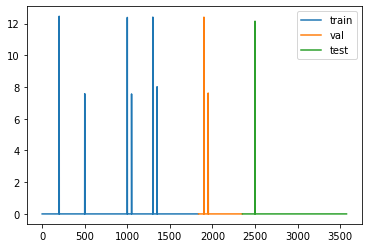

In [144]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

#ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [150]:
b.max()

tensor(12.1544)

In [96]:
max_list = []
idx_list = []
count=0
for i in np.concatenate([c,b,a]):
    if i > 10:
        max_list.append(i)
        idx_list.append(count)
    count+=1

In [97]:
normal = np.array(max_list[:9])
attack = np.array(max_list[11:])

In [113]:
b.max()

tensor(7.2493)

In [89]:
normal.max(),normal.min()

(12.354193, 12.354193)

In [69]:
#normal.max(),normal.min()

(12.465238, 12.390076)

In [97]:
path = 'Models/publication/predict lka/bin/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

testing...


  2%|▏         | 9/515 [00:00<00:05, 88.69it/s]it/s]

testing...


  1%|          | 9/1224 [00:00<00:13, 89.26it/s]s]

testing...


...

  1%|          | 9/1224 [00:00<00:13, 89.58it/s]s]

testing...


  5%|▌         | 66/1224 [00:00<00:09, 121.34it/s]

fake


 99%|█████████▉| 1211/1224 [00:08<00:00, 138.99it/s]

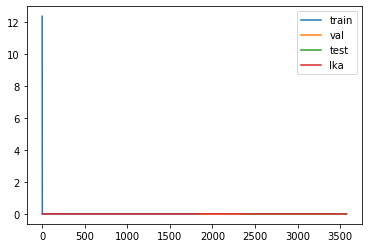

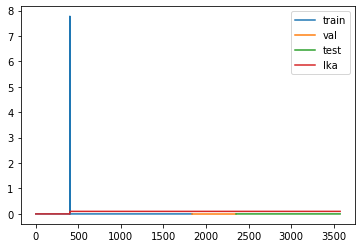

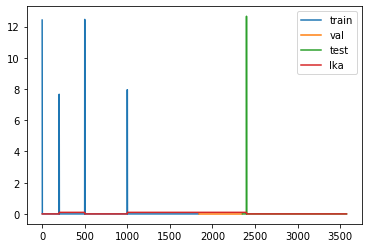

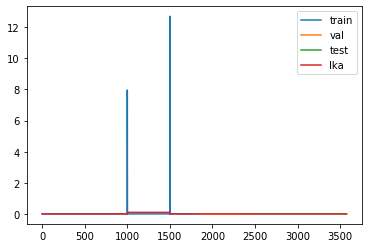

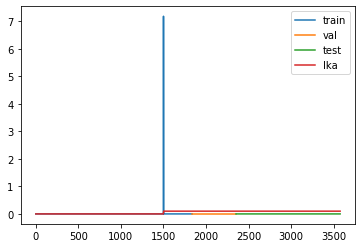

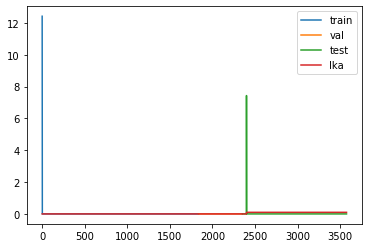

In [46]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(88).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.1 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/predict lka/bin/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

# Model : Predict lka 2
Input: VIS History + Previous VIS + VIS + previous LKA <br>
Input Form: Full frame<br>
Output: Prediction   LKA <br>
Training Dataset: Original<br>

In [41]:
def get_vis(frame):
    new_frame = frame.type(torch.int).tolist()
    new_frame = [str(i) for i in new_frame]
    s = ''.join(new_frame)
    new_frame = s[-4:] + s[:8]
    
    return (int(new_frame,2) *0.01)-16

In [56]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*4,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(256*4,88),
                                            nn.Sigmoid())
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        
        self.c = 0
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.vis_values = []
        self.vis_idx = []
        
        self.c =0
        self.art_lka = []
        self.test = False
        self.max_count= 2352
    def forward(self,x):
        self.lka =torch.zeros(88).cuda()
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
            vis_value = get_vis(self.vis[28:28+16].data)
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*80)
        
        if self.c==0 and not self.test:
            idx = random.randint(0,3)
            self.art_lka = torch.randint(0,1000,(1,(idx*2)+1)).tolist()[0]
            print(self.art_lka)
            

        if self.c in self.art_lka:
            print('fake')
            self.lka =torch.logical_xor(self.lka.type(torch.BoolTensor),torch.ones_like(self.lka).type(torch.BoolTensor)).type(torch.FloatTensor).cuda()

            #if self.lka[0]: 
            #    self.lka = torch.zeros(88).cuda()
            #else:
            #    print('yes')
            #    self.lka = torch.ones(88).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(torch.cat([self.vis,self.previous_vis,history,self.previous_lka]))

        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        self.previous_lka = self.lka.detach().cuda()
        
        self.flag_list.append([self.lka.detach().cpu(),self.vis_values[-1]])
        self.c = (self.c + 1) % self.max_count
        return None,self.lka,None,predected_lka


In [70]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*4,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        
        self.c = 0
        self.previous_states_conv = nn.Conv1d(2,1,(1))
        
        self.vis_values = []
        self.vis_idx = []
    def forward(self,x):   
        self.c +=1
        input_list = x.view(160,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(160,-1)[vis_idx[0]][120:208]
            vis_value = get_vis(self.vis[28:28+16].data)
            self.vis_values.append(vis_value)
            self.vis_idx.append(vis_idx + (self.c-1)*160)
        if lka_idx.size  :
            print(self.c)
            if self.lka[0]: 
                self.lka = torch.zeros(88).cuda()
            else:
                print('yes')
                self.lka = torch.ones(88).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.vis,self.previous_vis,history,self.previous_lka])))
        torch.sigmoid_(predected_lka)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        self.previous_lka = self.lka.detach().cuda()
        
        return None,self.lka,None,predected_lka


In [57]:
m =  unet_seq(bs,seq_len).cuda()

In [58]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [59]:
trn_item = Validate(trn_dl)
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [60]:
m.test = False
m.max_count = len(trn_dl)+len(v4_val_dl)

In [61]:
loss =binary()

In [32]:
cbs.load_all('publication/predict lka 2/bin/',model=m,opt=opt,learn=learn)

In [62]:
learn.fit(m , opt , 4 , dl,loss  )

[964, 434, 487, 673, 284]


IndexError: list index out of range

In [49]:
m.test = True
m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
#m.lka = torch.zeros(88).type(torch.FloatTensor).cuda()
l = [[],[400],[200,500,1000,2400],[1000,1500],[1500],[2400],[100,200,400,500,900,1000,1200,1300,1400,1500,1600,1700,1800,1900,2000,2100,2000,2300,2400,2500]]
m.art_lka = l[6]

In [50]:
trn_item.evaluate(model = m , crit = loss)
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  7%|▋         | 126/1837 [00:00<00:12, 135.85it/s]

fake


 12%|█▏        | 225/1837 [00:01<00:11, 139.50it/s]

fake


...

  5%|▌         | 67/1224 [00:00<00:09, 126.57it/s]

fake


 13%|█▎        | 165/1224 [00:01<00:07, 136.25it/s]

fake


 99%|█████████▉| 1211/1224 [00:08<00:00, 139.92it/s]

In [51]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [52]:
#index 203735 in the sheet

In [53]:
lka = [i[0][0]for i in m.flag_list]
vis = [i[1][0]for i in m.flag_list]

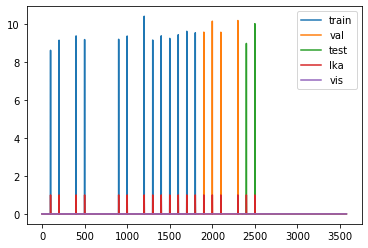

In [54]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c),label='train')
ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
ax.plot(range(len(vis[-3576:])),vis[-3576:],label='vis')
#ax.plot(range(len(lka)),lka,label='lka')
ax.legend()


In [ ]:
len(trn_dl)+len(v4_val_dl)+ len(v4_anml_dl)

In [116]:
for i in np.concatenate([c,b,a]):
    if i > 8:
        max_list.append(i)

In [117]:
max_list

[9.667162,
 9.582407,
 9.645661,
 9.814267,
 9.559921,
 9.814267,
 10.253651,
 10.253651,
 9.559921]

In [80]:
max_list=[]

In [34]:
#path = 'Models/publication/predict lka 2/SSIM/'
#cbs.save_all(path,model=m,learn=learn,opt=opt)

  1%|          | 10/1837 [00:00<00:19, 95.34it/s]

testing...


  2%|▏         | 10/515 [00:00<00:05, 99.91it/s]t/s]

testing...


  1%|          | 9/1224 [00:00<00:13, 88.21it/s]s]

...

 23%|██▎       | 116/515 [00:01<00:03, 121.59it/s]

fake


  1%|          | 10/1224 [00:00<00:12, 96.48it/s]]

testing...


 99%|█████████▉| 1212/1224 [00:08<00:00, 139.17it/s]

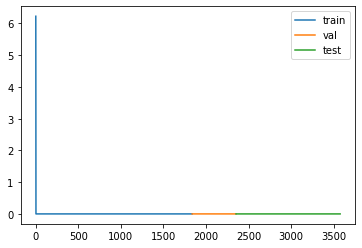

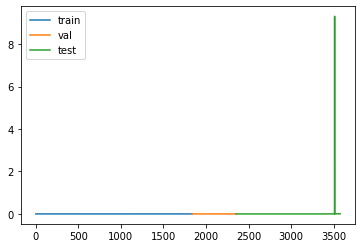

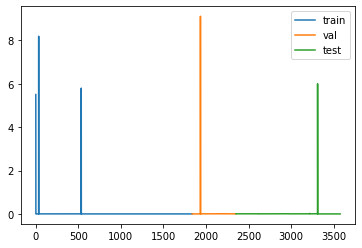

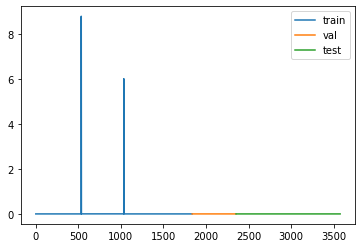

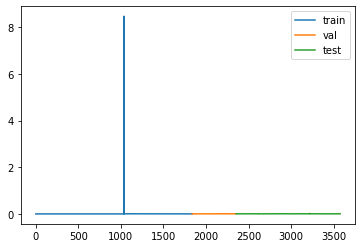

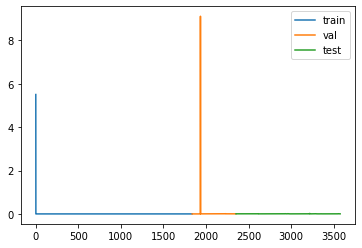

In [50]:
for i in range(1,7,1):
    m.test = True
    m.max_count = len(trn_dl)+len(v4_val_dl) + len(v4_anml_dl)
    m.lka = torch.zeros(88).type(torch.FloatTensor).cuda()
    m.art_lka = l[i-1]
    
    trn_item.evaluate(model = m , crit = loss)
    val2_item.evaluate(model = m , crit = loss)
    v4_anml_item.evaluate(model = m , crit = loss)
    
    a = torch.tensor(val2_item.test_loss)#.median() # Validation
    b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
    c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
    
    lka = [i[0][0]*0.5 for i in m.flag_list]
    
    fig,ax = plt.subplots()
    ax.plot(range(len(c)),list(c),label='train')
    ax.plot(range(len(c),len(c)+len(a)),list(a),label='val')
    ax.plot(range(len(c)+len(a),len(a)+len(b)+len(c)),list(b),label='test')

    #ax.plot(range(len(lka[-3576:])),lka[-3576:],label='lka')
    #ax.plot(range(len(lka)),lka,label='lka')
    ax.legend()

    
    path = f'Models/publication/predict lka 2/bin/{i}/'
    fig.savefig(f'{path}i.png')
    save(path,[a,b,c],names=['normal','attack','train'])

In [71]:
m =  unet_seq(bs,seq_len).cuda()

In [108]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [109]:
trn_item = Validate(trn_dl)

In [110]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [111]:
m.lka = torch.zeros_like(m.lka).cuda()

In [112]:
path = 'documentation/lka/lka given vis/1/bin/'
#cbs.load_all(path,model = m,learn=learn,opt=opt )

In [113]:
loss = binary()

In [114]:
learn.fit(m , opt , 1 , dl,loss  )

 29%|██▉       | 265/912 [00:04<00:09, 69.72it/s, loss : 0.21904272403357164]

2034
yes


 98%|█████████▊| 249/255 [00:03<00:00, 72.39it/s, loss : 0.00029473602173318825]

train Loss:  0.11764571815729141   validation loss:  0.0002943820145446807
tensor(nan)


In [115]:
#m.load_state_dict(torch.load('Models/documentation/lka/predict lka given vis and past lka/1/BaseModel'))

In [116]:
m.lka = torch.zeros_like(m.lka).cuda()
#m.previous_states = torch.zeros_like(m.previous_states).cuda()
#m.previous_vis = torch.zeros_like(m.previous_vis).cuda()


In [117]:
m.c = 0
m.vis_idx = []
m.vis_values = []

In [118]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/912 [00:00<?, ?it/s]

testing...


 29%|██▉       | 265/912 [00:03<00:09, 71.63it/s]

259
yes


 99%|█████████▉| 905/912 [00:12<00:00, 70.91it/s]

In [119]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  2%|▏         | 5/255 [00:00<00:06, 38.89it/s]

testing...


  1%|          | 5/608 [00:00<00:15, 38.23it/s]s]

testing...


  5%|▍         | 29/608 [00:00<00:10, 53.71it/s]

1191


100%|█████████▉| 605/608 [00:08<00:00, 72.17it/s]

In [120]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

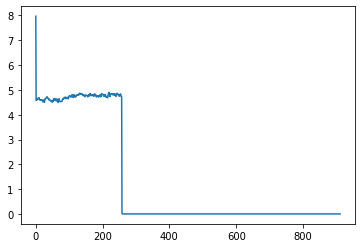

In [121]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

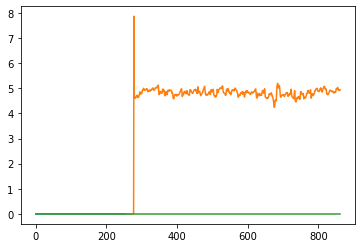

In [122]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

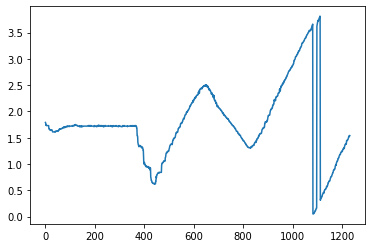

In [123]:
fig,ax = plt.subplots()
ax.plot(range(len(m.vis_values)),m.vis_values)


### second

In [644]:
m.lka = torch.zeros_like(m.lka).cuda()

In [645]:
learn.fit(m , opt , 1 , dl,loss  )

 37%|███▋      | 382/1023 [00:05<00:08, 71.54it/s, loss : 0.056021930035496256]

3533
yes


 99%|█████████▉| 253/255 [00:03<00:00, 70.31it/s, loss : 0.00012304217153387108]

train Loss:  0.021648915484547615   validation loss:  0.00012286497803870589
tensor(nan)


In [646]:
#m.load_state_dict(torch.load('Models/documentation/lka/predict lka given vis and past lka/1/BaseModel'))

In [647]:
m.lka = torch.zeros_like(m.lka).cuda()
#m.previous_states = torch.zeros_like(m.previous_states).cuda()
#m.previous_vis = torch.zeros_like(m.previous_vis).cuda()


In [648]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/1023 [00:00<?, ?it/s]

testing...


 37%|███▋      | 380/1023 [00:05<00:09, 69.83it/s]

4811
yes


100%|██████████| 1023/1023 [00:14<00:00, 73.19it/s]

In [649]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  2%|▏         | 5/255 [00:00<00:06, 39.03it/s]

testing...


  1%|          | 5/608 [00:00<00:15, 39.92it/s]s]

testing...


  6%|▌         | 37/608 [00:00<00:09, 60.20it/s]

5744


 99%|█████████▉| 603/608 [00:08<00:00, 72.36it/s]

In [650]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

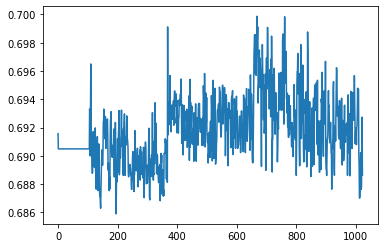

In [162]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

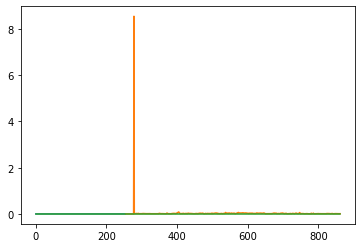

In [652]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

### Third

In [653]:
m.lka = torch.zeros_like(m.lka).cuda()

In [654]:
learn.fit(m , opt , 1 , dl,loss  )

 37%|███▋      | 383/1023 [00:05<00:08, 72.19it/s, loss : 0.01864366307271056]  

6697
yes


100%|██████████| 255/255 [00:03<00:00, 72.01it/s, loss : 3.879972386593912e-05] 

train Loss:  0.007097410038113594   validation loss:  3.879972791764885e-05
tensor(nan)


In [655]:
#m.load_state_dict(torch.load('Models/documentation/lka/predict lka given vis and past lka/1/BaseModel'))

In [656]:
m.lka = torch.zeros_like(m.lka).cuda()
#m.previous_states = torch.zeros_like(m.previous_states).cuda()
#m.previous_vis = torch.zeros_like(m.previous_vis).cuda()


In [657]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/1023 [00:00<?, ?it/s]

testing...


 37%|███▋      | 380/1023 [00:05<00:09, 68.12it/s]

7975
yes


100%|██████████| 1023/1023 [00:14<00:00, 73.40it/s]

In [658]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  2%|▏         | 4/255 [00:00<00:06, 39.27it/s]

testing...


  1%|          | 5/608 [00:00<00:15, 38.85it/s]s]

testing...


  6%|▌         | 37/608 [00:00<00:09, 59.52it/s]

8908


100%|██████████| 608/608 [00:08<00:00, 73.08it/s]

In [659]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

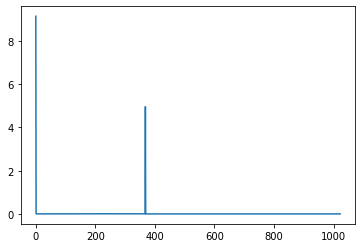

In [660]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

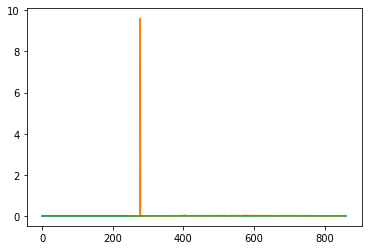

In [661]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

In [628]:
#path = 'Models/documentation/lka/lka given vis/1/ssim/'
#save(path,[a,b,c],names=['normal','attack','train'])

In [629]:
#cbs.save_all(path,model=m,learn=learn,opt=opt)